In [ ]:
# importing the libraries required for the model to perform

In [ ]:
import kagglehub
path = kagglehub.dataset_download("stealthtechnologies/employee-attrition-dataset")
print("Path to dataset files:", path)

100%|██████████| 1.72M/1.72M [00:00<00:00, 214MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/stealthtechnologies/employee-attrition-dataset/versions/2


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    ConfusionMatrixDisplay
)

In [ ]:
#loading the train and dataset

In [ ]:
train_df = pd.read_csv("/root/.cache/kagglehub/datasets/stealthtechnologies/employee-attrition-dataset/versions/2/train.csv")
display(train_df.head())

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed


In [ ]:
test_df = pd.read_csv("/root/.cache/kagglehub/datasets/stealthtechnologies/employee-attrition-dataset/versions/2/test.csv")
display(test_df.head())

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,52685,36,Male,13,Healthcare,8029,Excellent,High,Average,1,...,1,Mid,Large,22,No,No,No,Poor,Medium,Stayed
1,30585,35,Male,7,Education,4563,Good,High,Average,1,...,4,Entry,Medium,27,No,No,No,Good,High,Left
2,54656,50,Male,7,Education,5583,Fair,High,Average,3,...,2,Senior,Medium,76,No,No,Yes,Good,Low,Stayed
3,33442,58,Male,44,Media,5525,Fair,Very High,High,0,...,4,Entry,Medium,96,No,No,No,Poor,Low,Left
4,15667,39,Male,24,Education,4604,Good,High,Average,0,...,6,Mid,Large,45,Yes,No,No,Good,High,Stayed


In [ ]:
#eda checking the missing vakues

In [ ]:
print(train_df.isnull().sum())

Employee ID                 0
Age                         0
Gender                      0
Years at Company            0
Job Role                    0
Monthly Income              0
Work-Life Balance           0
Job Satisfaction            0
Performance Rating          0
Number of Promotions        0
Overtime                    0
Distance from Home          0
Education Level             0
Marital Status              0
Number of Dependents        0
Job Level                   0
Company Size                0
Company Tenure              0
Remote Work                 0
Leadership Opportunities    0
Innovation Opportunities    0
Company Reputation          0
Employee Recognition        0
Attrition                   0
dtype: int64


In [ ]:
#checking for duplicate values
print("Duplicate rows :", train_df.duplicated().sum())

Duplicate rows : 0


checking the distribution for the classes ( stayed and left)

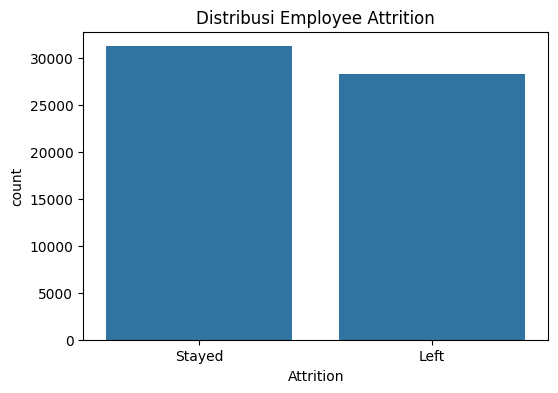

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=train_df,
    x='Attrition'
)

plt.title('Distribusi Employee Attrition')
plt.show()

normalization method used

In [ ]:
print(train_df['Attrition'].value_counts())
print(train_df['Attrition'].value_counts(normalize=True)*100)

Attrition
Stayed    31260
Left      28338
Name: count, dtype: int64
Attrition
Stayed    52.451425
Left      47.548575
Name: proportion, dtype: float64


preprocessing

In [ ]:
X_train = train_df.drop(columns=['Employee ID', 'Attrition'])
y_train = train_df['Attrition']

In [ ]:
X_test = test_df.drop(columns=['Employee ID', 'Attrition'])
y_test = test_df['Attrition']

In [ ]:
numerical_cols = [
    'Age',
    'Years at Company',
    'Monthly Income',
    'Number of Promotions',
    'Distance from Home',
    'Company Tenure',
    'Number of Dependents'
]

In [ ]:
scaler = StandardScaler()

In [ ]:
X_train_numerical_scaled = scaler.fit_transform(X_train[numerical_cols])
X_test_numerical_scaled = scaler.transform(X_test[numerical_cols])

In [ ]:
X_train_numerical_scaled_df = pd.DataFrame(X_train_numerical_scaled, columns=numerical_cols, index=X_train.index)
X_test_numerical_scaled_df = pd.DataFrame(X_test_numerical_scaled, columns=numerical_cols, index=X_test.index)

target encoding

In [ ]:
target_encoder = LabelEncoder()

In [ ]:
y_train = target_encoder.fit_transform(y_train)
y_test = target_encoder.transform(y_test)

non numerical encoding

In [ ]:
onehot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [ ]:
categorical_cols = X_train.select_dtypes(include='object').columns.tolist()

In [ ]:
X_train_categorical_encoded = onehot_encoder.fit_transform(X_train[categorical_cols])
X_test_categorical_encoded = onehot_encoder.transform(X_test[categorical_cols])

In [ ]:
encoded_feature_names = onehot_encoder.get_feature_names_out(categorical_cols)

In [ ]:
X_train_categorical_encoded_df = pd.DataFrame(X_train_categorical_encoded, columns=encoded_feature_names, index=X_train.index)
X_test_categorical_encoded_df = pd.DataFrame(X_test_categorical_encoded, columns=encoded_feature_names, index=X_test.index)

merging both data

In [ ]:
X_train_scaled = pd.concat([X_train_numerical_scaled_df, X_train_categorical_encoded_df], axis=1)
X_test_scaled = pd.concat([X_test_numerical_scaled_df, X_test_categorical_encoded_df], axis=1)

In [ ]:
all_processed_cols = X_train_scaled.columns.union(X_test_scaled.columns)
X_train_scaled = X_train_scaled.reindex(columns=all_processed_cols, fill_value=0)
X_test_scaled = X_test_scaled.reindex(columns=all_processed_cols, fill_value=0)

In [ ]:
print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled :", X_test_scaled.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train_scaled: (59598, 56)
X_test_scaled : (14900, 56)
y_train: (59598,)
y_test : (14900,)


first implementattion of the model implementing random forest

In [ ]:
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

In [ ]:
rf.fit(X_train_scaled, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [ ]:
y_pred = rf.predict(X_test_scaled)
y_proba = rf.predict_proba(X_test_scaled)[:, 1]

model evaluation for the first model

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
precision = precision_score(y_test, y_pred)
print(f"Precision: {precision:.4f}")
recall = recall_score(y_test, y_pred)
print(f"Recall: {recall:.4f}")
f1 = f1_score(y_test, y_pred)
print(f"F1 Score: {f1:.4f}")
auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC: {auc:.4f}")

Accuracy: 0.7493
Precision: 0.7633
Recall: 0.7613
F1 Score: 0.7623
ROC-AUC: 0.8372


feature analysis

In [ ]:
importance = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

hyperparameter tuning

randomized search

In [ ]:
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'criterion': ['gini', 'entropy'],
    'ccp_alpha': [0.0, 0.001, 0.005]
}

In [ ]:
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,
    scoring='f1',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    return_train_score=True
)

In [ ]:
random_search.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


RandomizedSearchCV(cv=5,
                   estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'ccp_alpha': [0.0, 0.001, 0.005],
                                        'criterion': ['gini', 'entropy'],
                                        'max_depth': [10, 20, 30, None],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, return_train_score=True, scoring='f1',
                   verbose=2)

finding the best configurationfor the current dataset

In [ ]:
print("Best Parameters:")
print(random_search.best_params_)

Best Parameters:
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 30, 'criterion': 'entropy', 'ccp_alpha': 0.0}


In [ ]:
print("Best CV F1:")
print(random_search.best_score_)

Best CV F1:
0.7644228053465578


In [ ]:
best_rf = random_search.best_estimator_

modelevaluation for the best parameter tuned model

In [ ]:
y_pred_tuned = best_rf.predict(X_test_scaled)
y_proba_tuned = best_rf.predict_proba(X_test_scaled)[:,1]

In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred_tuned))
print("Precision:", precision_score(y_test, y_pred_tuned))
print("Recall   :", recall_score(y_test, y_pred_tuned))
print("F1 Score :", f1_score(y_test, y_pred_tuned))
print("ROC AUC  :", roc_auc_score(y_test, y_proba_tuned))

Accuracy : 0.7538926174496644
Precision: 0.7619403915700212
Recall   : 0.7765632943568886
F1 Score : 0.7691823503493422
ROC AUC  : 0.844400812351467


In [ ]:
from google.colab import files
import joblib

# 1. Save the model using joblib
joblib.dump(best_rf, "best_rf.joblib")

# 2. Download the file to your computer
files.download("best_rf.joblib")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import joblib

# 1. Package the encoder and the target column names together
encoder_artifact = {
    'encoder': onehot_encoder,
    'categorical_cols': categorical_cols
}

# 2. Save the artifact to a file
joblib.dump(encoder_artifact, 'rf_onehot_encoder.joblib')
print("Encoder and column list successfully saved!")


Encoder and column list successfully saved!


In [ ]:
from google.colab import files
files.download('rf_onehot_encoder.joblib')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>